In [1]:
import cvxpy as cp

from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

import numpy as np

import matplotlib.pyplot as plt

Sets up an optimization-based controller using the SymPy derivations in the accompanying notebook.

In [57]:
u_f_var = cp.Variable(name="u_f")
u_t_var = cp.Variable(name="u_t")

u = cp.Variable((2,), name="u")

delta_var = cp.Variable(name="delta")

p_param = cp.Parameter(name="p", nonneg=True)
alpha_param, beta_param = (
    cp.Parameter(name="alpha", nonneg=True),
    cp.Parameter(name="beta", nonneg=True),
)

x_param, y_param, theta_param, v_param, omega_param = (
    cp.Parameter(name="x"),
    cp.Parameter(name="y"),
    cp.Parameter(name="theta"),
    cp.Parameter(name="v"),
    cp.Parameter(name="omega"),
)

x_traj_param, y_traj_param, theta_traj_param = (
    cp.Parameter(name="x_traj"),
    cp.Parameter(name="y_traj"),
    cp.Parameter(name="theta_traj"),
)
dot_x_traj_param, dot_y_traj_param, dot_theta_traj_param = (
    cp.Parameter(name="dot_x_traj"),
    cp.Parameter(name="dot_y_traj"),
    cp.Parameter(name="dot_theta_traj"),
)

# auxiliarly variables to represent the sin and cosine
aux_sin_theta_param = cp.Parameter(name="aux_sin_theta")
aux_cos_theta_param = cp.Parameter(name="aux_cos_theta")

In [58]:
# defines the cost to minimize controller action
cost = (
    0.5 * cp.quad_form(u, np.eye(2))
    # 1 / 2 * cp.square(u_f_var)
    # + 1 / 2 * cp.square(u_t_var)
    + p_param * cp.square(delta_var)
)

# defines the CLF constraint
Lf_Lf_v = (
    alpha_param * cp.square(v_param)
    + (
        alpha_param * (x_traj_param - x_param) * aux_sin_theta_param * v_param
        - alpha_param * (y_traj_param - y_param) * aux_sin_theta_param * v_param
        + beta_param * omega_param
    )
    * omega_param
)
Lf1_Lf_v = alpha_param * (
    (x_param - x_traj_param) * aux_cos_theta_param
    + (y_param - y_traj_param) * aux_sin_theta_param
)
Lf2_Lf_v = beta_param * (theta_param - theta_traj_param)
dv_dt = (
    alpha_param
    * (
        (x_traj_param - x_param) * dot_x_traj_param
        + (y_traj_param - y_param) * dot_y_traj_param
    )
    + beta_param * (theta_traj_param - theta_param) * dot_theta_traj_param
)

clf_constraint = (
    Lf_Lf_v + cp.bmat([[Lf1_Lf_v, Lf2_Lf_v]]) @ u <= delta_var
)

display(cost)
display(clf_constraint)

display(clf_constraint.is_dcp())

Expression(CONVEX, NONNEGATIVE, ())

Inequality(Expression(AFFINE, UNKNOWN, (1,)))

True

In [59]:
opt_cntrlr = cp.Problem(cp.Minimize(cost), [clf_constraint, delta_var >= 0])
display(opt_cntrlr)

Problem(Minimize(Expression(CONVEX, NONNEGATIVE, ())), [Inequality(Expression(AFFINE, UNKNOWN, (1,))), Inequality(Constant(CONSTANT, ZERO, ()))])

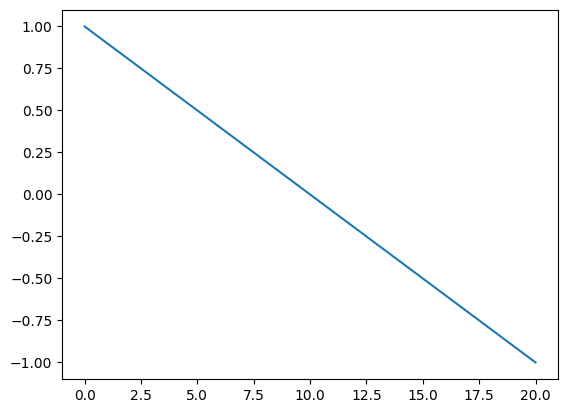

In [60]:
t_f = 20.0
dt = 0.01

n_samples = int(t_f / dt)

spline_method = CubicSpline

t = np.linspace(0, t_f, n_samples)
path_points = np.array([(0.0, 0.0, 0.0), (5.0, 5.0, 10.0), (10.0, 0.0, 20.0)])

x_spline, y_spline = (
    spline_method(path_points[:, 2], path_points[:, 0]),
    spline_method(path_points[:, 2], path_points[:, 1]),
)
x_traj, y_traj, dot_x_traj, dot_y_traj = (
    x_spline(t),
    y_spline(t),
    x_spline.derivative()(t),
    y_spline.derivative()(t),
)

theta_traj, dot_theta_traj = (
    np.atan2(y_traj, x_traj),
    np.atan2(dot_y_traj, dot_x_traj),
)

fig, ax = plt.subplots()
ax.plot(t, dot_y_traj)
plt.show()

In [61]:
def dyn_unicycle_f(t, p, u):
    x, y, theta, v, omega = p
    u_f, u_t = u

    dot_p = np.array([v * np.cos(theta), v * np.sin(theta), omega, u_f, u_t])
    return dot_p


# configure parameters
alpha_param.value = 1.0
beta_param.value = 0.5
p_param.value = 1.0

p0 = np.array([0.0, 0.0, np.pi / 2, 0.0, 0.0])
u0 = np.array([0.0, 0.0])

p_hist = []
u_hist = []

p_curr = p0
u_curr = u0
for i in range(len(t)):
    p_hist.append(p_curr)
    u_hist.append(u_curr)

    # gets the current state and trajectory
    x_curr, y_curr, theta_curr, v_curr, omega_curr = p_curr
    x_traj_curr, y_traj_curr, theta_traj_curr = (x_traj[i], y_traj[i], theta_traj[i])
    dot_x_traj_curr, dot_y_traj_curr, dot_theta_traj_curr = (
        dot_x_traj[i],
        dot_y_traj[i],
        dot_theta_traj[i],
    )

    # sets the values in the optimization program
    x_param.value = x_curr
    y_param.value = y_curr
    theta_param.value = theta_curr
    v_param.value = v_curr
    omega_param.value = omega_curr

    x_traj_param.value = x_traj_curr
    y_traj_param.value = y_traj_curr
    theta_traj_param.value = theta_traj_curr

    dot_x_traj_param.value = dot_x_traj_curr
    dot_y_traj_param.value = dot_y_traj_curr
    dot_theta_traj_param.value = dot_theta_traj_curr

    aux_sin_theta_param.value = np.sin(theta_curr)
    aux_cos_theta_param.value = np.cos(theta_curr)

    # generate controls from optimization scheme
    opt_cntrlr_result = opt_cntrlr.solve()

    u_f_optim = u.value[0]
    u_t_optim = u.value[1]
    delta_optim = delta_var.value

    print(f"t: {t[i]}, u_f: {u_f_optim}, u_t: {u_t_optim}, delta: {delta_optim}")

    # run the dynamics assuming the controls remain constant
    ivp_result = solve_ivp(
        lambda t, y: dyn_unicycle_f(t, y, u=np.array([u_f_optim, u_t_optim])),
        [0.0, dt],
        p_curr,
    )
    p_curr = ivp_result.y[:, -1]

    if i > 100:
        break

/home/samuel/Documents/School/UWaterloo_MASc/Research_Activities/research-geo-diff-opt-layer/.venv/lib/python3.12/site-packages/cvxpy/reductions/solvers/solving_chain.py:242: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)


Polishing not needed - no active set detected at optimal point
t: 0.0, u_f: 0.0, u_t: 0.0, delta: 0.0
ERROR in osqp_update_data_mat: new number of elements (4) out of bounds for A (3 max)
Polishing not needed - no active set detected at optimal point
t: 0.010005002501250625, u_f: 0.0, u_t: 0.0, delta: 0.0
ERROR in osqp_update_data_mat: new number of elements (4) out of bounds for A (3 max)
Polishing not needed - no active set detected at optimal point
t: 0.02001000500250125, u_f: 0.0, u_t: 0.0, delta: 0.0
ERROR in osqp_update_data_mat: new number of elements (4) out of bounds for A (3 max)
Polishing not needed - no active set detected at optimal point
t: 0.030015007503751877, u_f: 0.0, u_t: 0.0, delta: 0.0
ERROR in osqp_update_data_mat: new number of elements (4) out of bounds for A (3 max)
Polishing not needed - no active set detected at optimal point
t: 0.0400200100050025, u_f: 0.0, u_t: 0.0, delta: 0.0
ERROR in osqp_update_data_mat: new number of elements (4) out of bounds for A (3 

In [8]:
opt_cntrlr.get_problem_data(solver=cp.OSQP)[0]

/home/samuel/Documents/School/UWaterloo_MASc/Research_Activities/research-geo-diff-opt-layer/.venv/lib/python3.12/site-packages/cvxpy/reductions/solvers/solving_chain.py:242: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  warnings.warn(DPP_ERROR_MSG)


{'dims': (zero: 0, nonpos: 1, exp: 0, soc: [], psd: []),
 'param_prob': <cvxpy.reductions.qp2quad_form.qp_matrix_stuffing.ParamQuadProg at 0x791cb59823c0>,
 'P': <Compressed Sparse Column sparse array of dtype 'float64'
 	with 3 stored elements and shape (3, 3)>,
 'q': array([0., 0., 0.]),
 'A': <Compressed Sparse Column sparse array of dtype 'float64'
 	with 0 stored elements and shape (0, 3)>,
 'b': array([], dtype=float64),
 'F': <Compressed Sparse Column sparse array of dtype 'float64'
 	with 3 stored elements and shape (1, 3)>,
 'G': array([-0.87411266]),
 'bool_vars_idx': [],
 'int_vars_idx': [],
 'lower_bounds': None,
 'upper_bounds': None,
 'n_var': 3,
 'n_eq': 0,
 'n_ineq': 1}